In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import warnings; warnings.simplefilter('ignore')
import spatialdata as sd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import senepy as sp
import scanpy as sc
import anndata as ad
import pandas as pd
import warnings; warnings.simplefilter('ignore')
import spatialdata as sd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.sparse as sparse
from typing import Optional, Tuple, Literal
import math



/home/lallen2/miniforge3/envs/spatial-clean/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


'/fh/fast/grady_w/users/lallen2/spatial/trio-tma-xenium/TRIO-TMA-WORKFLOW'

In [ ]:
import sys
from pathlib import Path

# Locate project root (folder containing config.yaml) and add scripts/ to sys.path
_p = Path.cwd().resolve()
while not (_p / 'config.yaml').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p / 'scripts'))
from paths import P, ensure_dirs

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
})

# Tell matplotlib to export text as TrueType fonts for PDF and PS/EPS

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# setup and io

In [3]:

ADATA_PATH  = str(P.processed.adata.all_cells / P.fn.all_cells_final)
SDATA_DIR   = str(P.interim.sdata)


In [ ]:
all_cells_adata = sc.read_h5ad(ADATA_PATH)
epi_adata = sc.read_h5ad(str(P.processed.adata.epithelial / "epithelial_20_50_harmony_batch_05_pt_05_ssg.h5ad"))
all_cells_adata = all_cells_adata[~all_cells_adata.obs['cell_id'].duplicated(keep=False)].copy()


In [6]:
fibroblast_anno = pd.read_csv(str(P.annotations / "nonepithelial" / "fibroblast_annotations.csv"))

fib_map = (
    fibroblast_anno
    .drop_duplicates(subset='cell_id')
    .set_index('cell_id')['fibroblast_annotation']
)

cols = [
    'annotation_final_fine', 'celltype_fine_epi_clusts', 'celltype_fine_epi_anno',
    'annotation_final_fine_cd8', 'celltype_fine_epi_clusts_cd8', 'celltype_fine_epi_anno_cd8',
]

for col in cols:
    # Convert categorical to string to avoid category issues
    all_cells_adata.obs[col] = all_cells_adata.obs[col].astype(str)
    mask = all_cells_adata.obs[col] == 'Fibroblasts'
    new_vals = all_cells_adata.obs.loc[mask, 'cell_id'].map(fib_map)
    all_cells_adata.obs.loc[mask, col] = new_vals.values


t_cell_anno = pd.read_csv(str(P.annotations / "nonepithelial" / "t-cell_annotations.csv"))


t_cell_anno['T-Cells_annotation'] = t_cell_anno['T-Cells_annotation'].replace({
    'T_Cells': 'T-Cells',
    'CD8_T_Cells': 'CD8-T-Cell',
})


tcell_map = (
    t_cell_anno
    .drop_duplicates(subset='cell_id')
    .set_index('cell_id')['T-Cells_annotation']
)

cols = [
    'annotation_final_fine_cd8', 'celltype_fine_epi_clusts_cd8', 'celltype_fine_epi_anno_cd8',
]

for col in cols:
    all_cells_adata.obs[col] = all_cells_adata.obs[col].astype(str)
    mask = all_cells_adata.obs[col].isin(['T-Cells', 'CD8-T-Cell'])
    old_vals = all_cells_adata.obs.loc[mask, col].copy()
    new_vals = all_cells_adata.obs.loc[mask, 'cell_id'].map(tcell_map)
    all_cells_adata.obs.loc[mask, col] = new_vals.values
    changed = (old_vals != new_vals.values).sum()
    print(f"{col}: {mask.sum()} cells matched, {changed} changed")

annotation_final_fine_cd8: 55845 cells matched, 8450 changed
celltype_fine_epi_clusts_cd8: 55845 cells matched, 8450 changed
celltype_fine_epi_anno_cd8: 55845 cells matched, 8450 changed


# spatialdata prep

In [7]:
def make_spatialdata_dict(spatialdata_dir):
    """Load all filtered/normalized SpatialData .zarr files into a dictionary."""
    spatialdata_dict = {}
    entries = [f for f in os.listdir(spatialdata_dir) if f.startswith("fil")]
    for filename in sorted(entries):
        sdata = sd.read_zarr(f"{spatialdata_dir}/{filename}")
        key = filename.replace('filtered_normalized_xenium_', '').replace('.zarr', '')
        spatialdata_dict[key] = sdata
    return spatialdata_dict


def transfer_obs_columns(spatialdata_dict, reference_adata, columns):
    """Transfer annotation columns from a reference AnnData to SpatialData tables (join on cell_id)."""
    ref_obs = reference_adata.obs.set_index('cell_id')[columns]
    for section_key, sdata in spatialdata_dict.items():
        table = sdata.tables['table']
        for col in columns:
            if col in ref_obs.columns:
                table.obs[col] = table.obs['cell_id'].map(ref_obs[col])
    return spatialdata_dict


spatialdata_dict = make_spatialdata_dict(SDATA_DIR)
print(f"Loaded {len(spatialdata_dict)} SpatialData sections")

version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


Loaded 2 SpatialData sections


In [9]:
# Identify valid (section, core) pairs
MIN_EPI_CELLS        = 100       # Minimum epithelial cells per core

epi_obs = all_cells_adata.obs[all_cells_adata.obs['annotation_final_fine_cd8'] == 'Epithelial']
epi_counts = epi_obs.groupby(['batch', 'core_id']).size()
valid_pairs = epi_counts[epi_counts >= MIN_EPI_CELLS].reset_index()
valid_section_cores = set(zip(valid_pairs['batch'], valid_pairs['core_id']))
print(f"Valid (section, core) pairs: {len(valid_section_cores)}")

# Filter spatialdata_dict — strict section assignment
valid_cell_ids = set(all_cells_adata.obs['cell_id'].unique())

filtered_spatialdata_dict = {}
for section_key, sdata in spatialdata_dict.items():
    table = sdata.tables['table']
    valid_cores_for_section = {
        core for (batch, core) in valid_section_cores if batch == section_key
    }
    mask = (
        table.obs['cell_id'].isin(valid_cell_ids)
        & table.obs['core_id'].isin(valid_cores_for_section)
    )
    if mask.sum() > 0:
        sdata.tables['table'] = table[mask].copy()
        filtered_spatialdata_dict[section_key] = sdata
        print(f"  {section_key}: {mask.sum()} cells, "
              f"{sdata.tables['table'].obs['core_id'].nunique()} cores")
    else:
        print(f"  {section_key}: dropped (no valid cells)")

# Verify no duplicate core assignments across sections
core_to_sections = {}
for section_key, sdata in filtered_spatialdata_dict.items():
    for core in sdata.tables['table'].obs['core_id'].unique():
        core_to_sections.setdefault(core, []).append(section_key)
duplicated = {c: s for c, s in core_to_sections.items() if len(s) > 1}
print(f"\nCores in multiple sections: {len(duplicated)}")
for core, sections in sorted(duplicated.items()):
    print(f"  {core}: {sections}")

Valid (section, core) pairs: 101
  A1: 409176 cells, 54 cores
  A2: 401190 cells, 47 cores

Cores in multiple sections: 0


In [10]:
TRANSFER_COLUMNS = [
    'annotation_final_fine', 'annotation_final_coarse',
    'tissue_type_cell_level', 'tissue_type_dysplasia_cell_level',
    'block_id', 'mixed_core_tissue_type', 'mixed_core_dysplasia',
    'is_mixed_tissue_type', 'is_mixed_dysplasia',
    'tissue_type_cell_level_normal_split',
    'tissue_type_dysplasia_cell_level_normal_split',
    'epithelial_0.8', 'cluster_annotations_0.8',
    'celltype_fine_epi_clusts', 'celltype_fine_epi_anno',
    'annotation_final_fine_cd8', 'celltype_fine_epi_clusts_cd8',
    'celltype_fine_epi_anno_cd8', 'GDF15_positive',
    'GDF15_more_than_1_transcript', 'senepy_intestine_epi_0',
    'stemness_score', 'senepy_high', 'core_id', 'patient_id',
]

filtered_spatialdata_dict = transfer_obs_columns(
    filtered_spatialdata_dict, all_cells_adata, TRANSFER_COLUMNS
)

# Sanity check
for section_key, sdata in filtered_spatialdata_dict.items():
    table = sdata.tables['table']
    n_epi = (table.obs['annotation_final_fine_cd8'] == 'Epithelial').sum()
    n_total = len(table)
    print(f"{section_key}: {n_total} total, {n_epi} epithelial ({100*n_epi/n_total:.1f}%)")

A1: 409176 total, 228773 epithelial (55.9%)
A2: 401190 total, 232936 epithelial (58.1%)


# all cells umaps and marker dotplots

In [11]:
all_cells_adata.obs["annotation_final_fine_cd8_combined"] = all_cells_adata.obs["annotation_final_fine_cd8"].astype(str).copy()

fib_mask = all_cells_adata.obs["annotation_final_fine_cd8_combined"].str.contains("Fibroblast|CAF", case=False, na=False)
all_cells_adata.obs.loc[fib_mask, "annotation_final_fine_cd8_combined"] = "Fibroblasts"
adata_filtered = all_cells_adata[all_cells_adata.obs["annotation_final_fine_cd8_combined"] != "Unknown"].copy()

# Define your desired order
category_order = [
    "Epithelial",
    "Fibroblasts",
    "Smooth Muscle",
    "Endothelial",
    "Pericytes",
    "Schwann Cells",
    "Plasma Cells",
    "B-Cells",
    "T-Cells",
    "CD8-T-Cell",
    "Myeloid Cells",
    "Mast Cells"
]

final_markers = ["EPCAM","LGALS3","TSPAN8","COL1A1","DCN","CXCL14","ACTA2","IGFBP5","IGFBP4","PLVAP","PECAM1","IGFBP7","COL4A1","MPZ","SCN7A","XBP1","MZB1","TENT5C","MS4A1","CD79A","PTPRC","CD3E","CD8A","CTSB","KIT","MS4A2"]
existing = set(adata_filtered.obs["annotation_final_fine_cd8_combined"].unique())
category_order = [c for c in category_order if c in existing]

In [12]:
output_dir = str(P.results.figures / "figure_1")

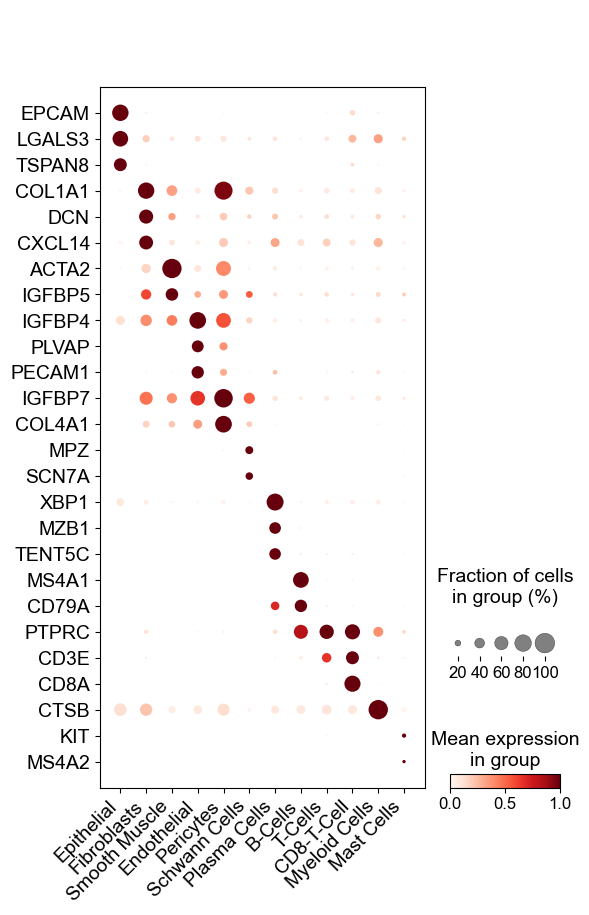

In [13]:
dp = sc.pl.dotplot(
    adata_filtered,
    var_names=final_markers,
    groupby="annotation_final_fine_cd8_combined",
    categories_order=category_order,
    standard_scale="var",
    return_fig=True,
    swap_axes=True,
)
dp.style(dot_edge_color="none")
ax_dict = dp.show(return_axes=True)

# Set tick label sizes
ax_dict["mainplot_ax"].tick_params(axis="both", labelsize=14)
ax_dict["mainplot_ax"].set_xticklabels(
    ax_dict["mainplot_ax"].get_xticklabels(), rotation=45, ha="right", fontsize=14
)

# If there's a color bar or size legend, adjust those too
for ax_name, ax in ax_dict.items():
    if ax_name != "mainplot_ax":
        ax.tick_params(labelsize=12)
        if ax.get_title():
            ax.set_title(ax.get_title(), fontsize=14)
plt.savefig(os.path.join(output_dir, "dotplot.pdf"), dpi=300, bbox_inches="tight")
plt.show()


In [14]:
colors_dict = {'B-Cells': '#009432ff',
 'Endothelial': "#521243ff",
 'Fibroblasts': "#ff9090",
 'Mast Cells': "#A9422A",
 'Myeloid Cells': '#006266ff',
 'Pericytes': '#81fcf8',
 'Plasma Cells': '#f79f1fff',
 'Schwann Cells': '#8643cc',
 'Smooth Muscle': '#1518c2',
 'T-Cells': '#c4e538ff',
 'CD8-T-Cell':"#EA2027",         
 'Epithelial': '#34ace0'}

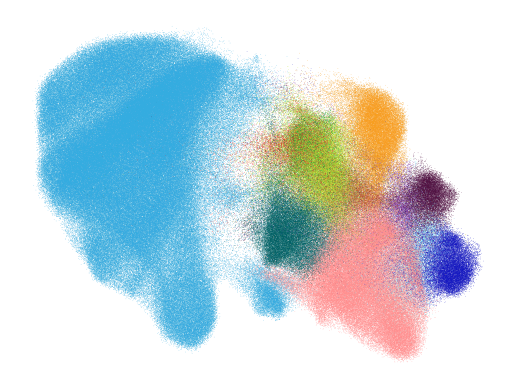

In [15]:
adata_filtered.obs["annotation_collapsed"] = adata_filtered.obs["annotation_final_fine_cd8"].copy()
adata_filtered.obs["annotation_collapsed"] = adata_filtered.obs["annotation_collapsed"].cat.add_categories("Fibroblasts")
fib_mask = adata_filtered.obs["annotation_collapsed"].str.contains("Fibroblast|CAF", case=False, na=False)
adata_filtered.obs.loc[fib_mask, "annotation_collapsed"] = "Fibroblasts"
adata_filtered.obs["annotation_collapsed"] = adata_filtered.obs["annotation_collapsed"].cat.remove_unused_categories()

sc.settings._vector_friendly = True

ax = sc.pl.umap(adata_filtered, color="annotation_collapsed", show=False, size=0.5, title=None, legend_loc="none", palette=colors_dict)
ax.set_title("")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "all_cells_umap.pdf"), dpi=300, bbox_inches="tight")
plt.show()

sc.settings._vector_friendly = False

In [16]:
import pandas as pd

obs = adata_filtered.obs.copy()

# 1) Epithelial cells: use their tissue_type value directly
epi_mask = obs['annotation_final_fine'] == 'Epithelial'
obs['combined_tissue_type_colors_plotting'] = ''

obs.loc[epi_mask, 'combined_tissue_type_colors_plotting'] = (
    obs.loc[epi_mask, 'tissue_type_cell_level_normal_split'].astype(str)
)

# 2) Non-epithelial cells: determine per-core tissue type using ONLY epithelial cells
epi_obs = obs.loc[epi_mask]
core_tissue = (
    epi_obs.loc[epi_obs['tissue_type_cell_level_normal_split'].notna()]
    .groupby('core_id')['tissue_type_cell_level_normal_split']
    .apply(lambda x: x.dropna().unique())
)

core_label = core_tissue.apply(lambda x: x[0] if len(x) == 1 else 'Mixed')

# Assign to non-epithelial cells
non_epi_mask = ~epi_mask
obs.loc[non_epi_mask, 'combined_tissue_type_colors_plotting'] = (
    obs.loc[non_epi_mask, 'core_id'].map(core_label)
)

adata_filtered.obs = obs

print(adata_filtered.obs['combined_tissue_type_colors_plotting'].value_counts())

combined_tissue_type_colors_plotting
TA            282578
CA            202999
separate_N    160065
N             121642
Mixed          30577
Name: count, dtype: int64


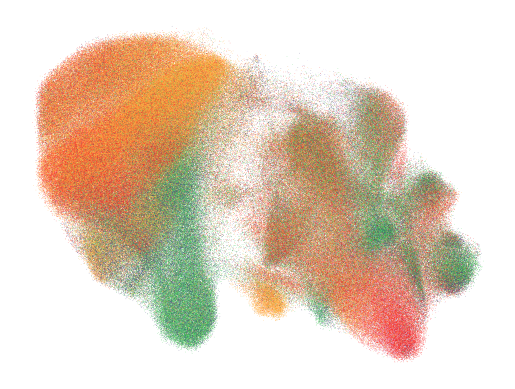

In [22]:
tissue_colors_normal_split = {'separate_N': "#3dcd55",'N': '#40407a', 'TA': '#ffb142', 'CA': '#fa2b2b', "Mixed":"#ddc2fc"}
sc.settings._vector_friendly = True
ax = sc.pl.umap(adata_filtered, color="combined_tissue_type_colors_plotting", show=False, size=0.5, title=None, legend_loc="none", palette=tissue_colors_normal_split)
ax.set_title("")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "all_cells_umap_by_tissue_type.pdf"), dpi=300, bbox_inches="tight")
plt.show()
sc.settings._vector_friendly = False

# Epithelial UMAPS

In [18]:
epi_adata

AnnData object with n_obs × n_vars = 458614 × 5050
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'DAPI_average', 'core_id', 'patient_id', 'tissue_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes', 'batch', 'mixed_core', 'mix_type', 'tissue_type_dysplasia', 'combo_all_cells_0.2', 'combo_all_cells_0.3', 'combo_all_cells_0.4', 'combo_all_cells_0.5', 'combo_all_cells_0.6', 'combo_all_cells_0.7', 'combo_all_cells_0.8', 'combo_all_cells_0.9', 'combo_all_cells_1.0', 'combo_all_cells_1.5', 'combo_all_cells_2.0', 'immune_anno_fine', 'stromal_anno_fine', 'annotation_final_fine',

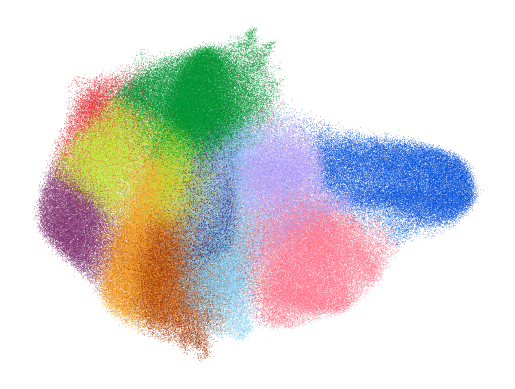

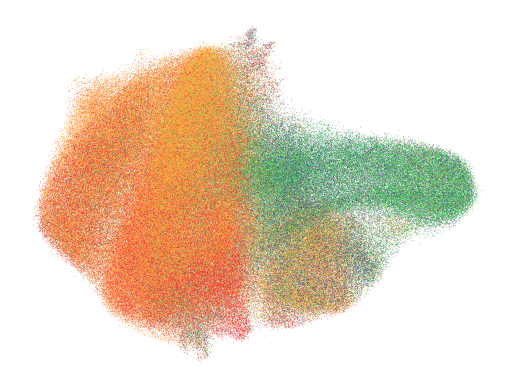

In [21]:
cluster_colors = {
    "0": '#009432',
    "1": '#C4E538',
    "2": "#FF788F",
    "3": "#85D5FB",
    "4": "#B3A1F9",
    "5": '#0652DD',
    "6": '#F79F1F',
    "7": "#a53707",
    "8": '#833471',
    "9": '#EA2027',
    "10": '#1B1464'
}
tissue_colors_normal_split = {'separate_N': "#3dcd55",'N': '#40407a', 'TA': '#ffb142', 'CA': "#fa2b2b"}
sc.settings._vector_friendly = True

ax = sc.pl.umap(epi_adata, color="epithelial_0.8", show=False,size=0.8,title=None, legend_loc="none", palette=cluster_colors)
ax.set_title("")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir,"epi_umap.pdf"), dpi=300, bbox_inches="tight")

plt.show()


ax = sc.pl.umap(epi_adata, color="tissue_type_cell_level_normal_split", show=False,size=0.8,title=None, legend_loc="none", palette=tissue_colors_normal_split)
ax.set_title("")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "epi_umap_by_tissue_type.pdf"), dpi=300, bbox_inches="tight")

plt.show()
sc.settings._vector_friendly = False

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Adjust order/colors above to match your palette

fig_leg, ax_leg = plt.subplots(1, 1, figsize=(4, 2))
ax_leg.axis("off")

handles = [mpatches.Patch(color=tissue_colors_normal_split[k], label=k) for k in tissue_colors_normal_split]
ax_leg.legend(handles=handles, title="", loc="center",
              fontsize=14, frameon=False, ncol=1,
              handlelength=1, handleheight=0.8, labelspacing=0.3)

fig_leg.tight_layout()
fig_leg.savefig(os.path.join(output_dir, "legend_tissue_type_split.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# GDF15 comparison boxplots

Cores with mixed epithelial tissue types:
Series([], Name: tissue_type_cell_level_normal_split, dtype: int64)

core_tissue_type value counts:
core_tissue_type
TA            264945
CA            204047
separate_N    162528
N             111659
NA                 0
Name: count, dtype: int64

=== Figure 1: Epithelial vs Non-epithelial ===
  n=16, p=1.5259e-05



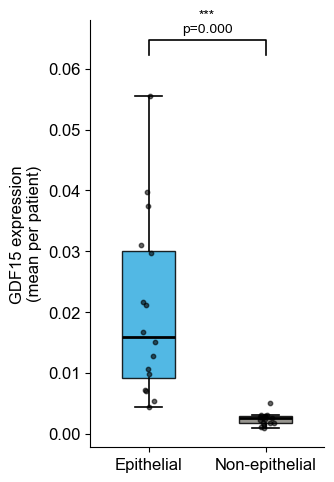

=== Figure 2: By coarse cell type ===
cell_type  n_paired     pval     padj
   Immune        16 0.000031 0.000031
  Stromal        16 0.000031 0.000031 



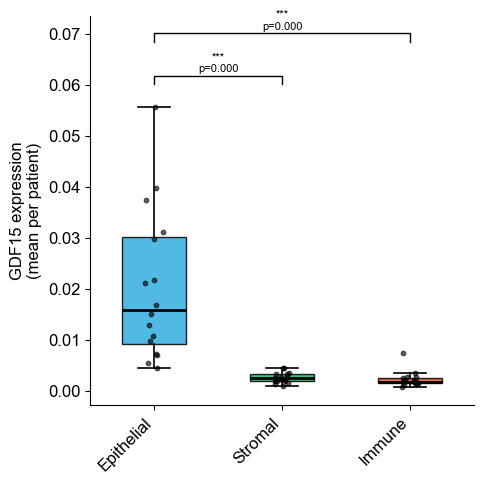

=== Figure 3: Epithelial vs Non-epithelial by tissue type ===
Tissue types found: ['CA', 'N', 'TA', 'separate_N']
  CA: n_paired=12
  N: n_paired=10
  TA: n_paired=13
  separate_N: n_paired=12
tissue_type  n_paired  epi_mean  non_epi_mean     pval     padj
         CA        12  0.032696      0.002615 0.000244 0.000488
          N        10  0.008287      0.001673 0.004883 0.004883
         TA        13  0.040189      0.003407 0.000122 0.000488
 separate_N        12  0.005409      0.001833 0.001709 0.002279 



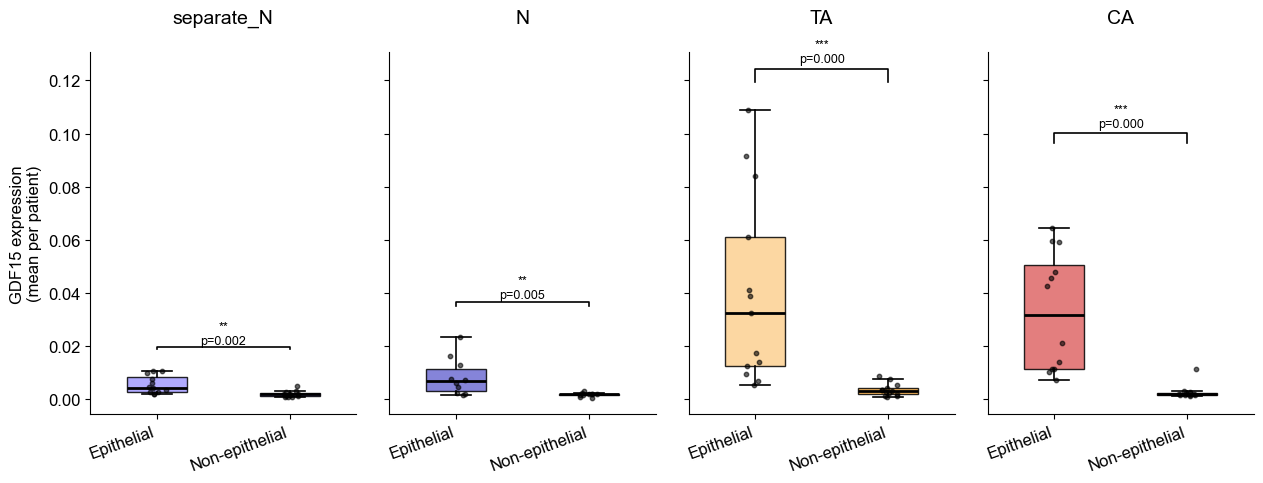

=== Figure 4: Epithelial vs Fibroblasts ===
  n=16, p=3.0518e-05



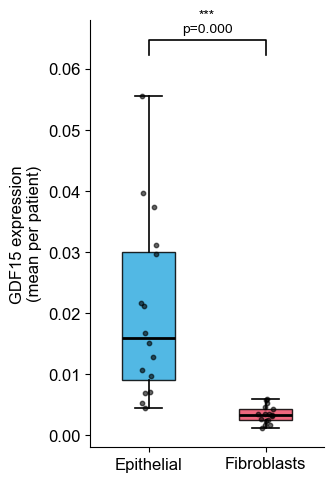

=== Figure 5: Epithelial vs Fibroblasts by tissue type ===
  CA: n_paired=12
  N: n_paired=10
  TA: n_paired=13
  separate_N: n_paired=12
tissue_type  n_paired  epi_mean  fib_mean     pval     padj
         CA        12  0.032696  0.002131 0.000244 0.000488
          N        10  0.008287  0.003328 0.065430 0.065430
         TA        13  0.040189  0.005265 0.000122 0.000488
 separate_N        12  0.005409  0.002964 0.046143 0.061523 



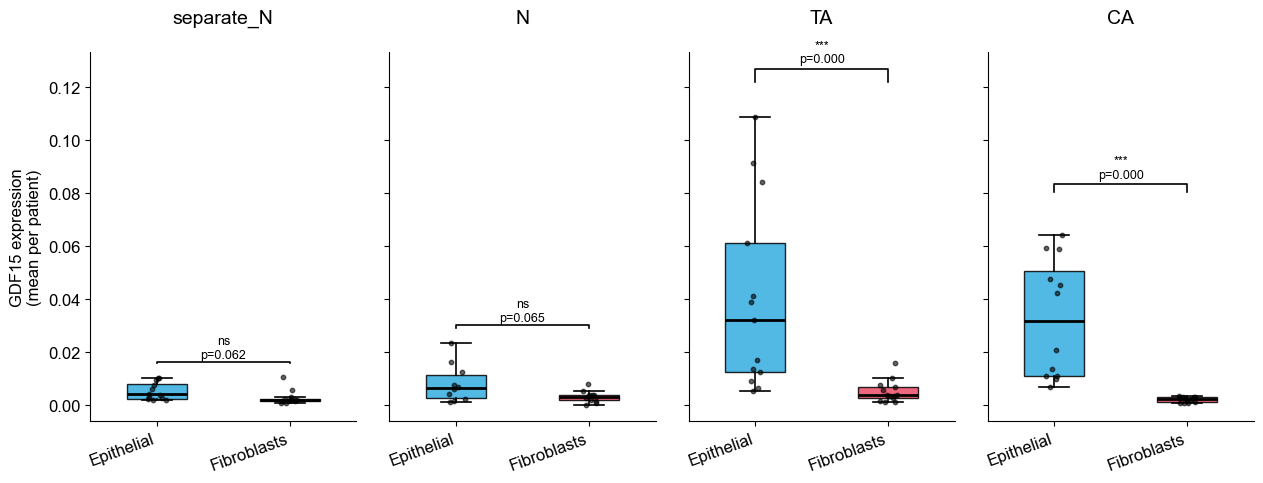

In [127]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

# plt.rcParams.update({
#     "font.family": "Arial",
#     "font.size": 12,
# })

# ── Output directory ─────────────────────────────────────────────────────────
output_dir = str(P.results.figures / "figure_1")  # <-- CHANGE THIS
os.makedirs(output_dir, exist_ok=True)

# ── Helper ───────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ══════════════════════════════════════════════════════════════════════════════
# EXTRACT EXPRESSION — all cells
# ══════════════════════════════════════════════════════════════════════════════
gene = "GDF15"
adata = all_cells_adata

gene_idx = adata.var_names.get_loc(gene)
X = adata.X
if sp.issparse(X):
    expr = np.array(X[:, gene_idx].todense()).flatten()
else:
    expr = X[:, gene_idx]

df_all = pd.DataFrame({
    "GDF15": expr,
    "core_id": adata.obs["core_id"].values,
    "patient_id": adata.obs["patient_id"].values,
    "cell_type_coarse": adata.obs["annotation_final_coarse"].values,
    "cell_type_fine": adata.obs["annotation_final_fine"].values,
})

# Collapse fibroblasts
fib_mask = df_all["cell_type_fine"].str.contains("Fibroblast|CAF", case=False, na=False)
df_all.loc[fib_mask, "cell_type_fine"] = "Fibroblasts"

# ══════════════════════════════════════════════════════════════════════════════
# SETUP FOR FIGURES 3 & 5: subset to non-mixed cores, derive core_tissue_type
# ══════════════════════════════════════════════════════════════════════════════
all_cells_adata_uniform = all_cells_adata[all_cells_adata.obs['mixed_core_tissue_type'] == False].copy()
epi_mask_u = all_cells_adata_uniform.obs['annotation_final_coarse'] == 'Epithelial'
epi_obs_u = all_cells_adata_uniform.obs[epi_mask_u]
core_tissue_map = epi_obs_u.groupby('core_id')['tissue_type_cell_level_normal_split'].first()

print("Cores with mixed epithelial tissue types:")
mixed = epi_obs_u.groupby('core_id')['tissue_type_cell_level_normal_split'].nunique()
print(mixed[mixed > 1])

all_cells_adata_uniform.obs['core_tissue_type'] = all_cells_adata_uniform.obs['core_id'].map(core_tissue_map)
print("\ncore_tissue_type value counts:")
print(all_cells_adata_uniform.obs['core_tissue_type'].value_counts())

adata_u = all_cells_adata_uniform
gene_idx_u = adata_u.var_names.get_loc(gene)
X_u = adata_u.X
if sp.issparse(X_u):
    expr_u = np.array(X_u[:, gene_idx_u].todense()).flatten()
else:
    expr_u = X_u[:, gene_idx_u]

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: GDF15 Epithelial vs Non-epithelial (all patients pooled)
# ══════════════════════════════════════════════════════════════════════════════
df1 = df_all.copy()
df1["is_epithelial"] = df1["cell_type_coarse"] == "Epithelial"

core_df = (
    df1.groupby(["patient_id", "core_id", "is_epithelial"])["GDF15"]
    .mean()
    .reset_index()
    .pivot_table(index=["patient_id", "core_id"], columns="is_epithelial", values="GDF15")
    .rename(columns={True: "epi_mean", False: "non_epi_mean"})
    .dropna()
    .reset_index()
)

patient_df = (
    core_df.groupby("patient_id")[["epi_mean", "non_epi_mean"]]
    .mean()
    .reset_index()
)

stat, pval1 = wilcoxon(patient_df["epi_mean"], patient_df["non_epi_mean"], alternative="greater")
print(f"\n=== Figure 1: Epithelial vs Non-epithelial ===")
print(f"  n={len(patient_df)}, p={pval1:.4e}\n")

fig, ax = plt.subplots(figsize=(3.5, 5))
data = [patient_df["epi_mean"].values, patient_df["non_epi_mean"].values]
colors = ["#34ace0", "#84817a"]
bp = ax.boxplot(data, positions=[0, 1], widths=0.45, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for i, col in enumerate(["epi_mean", "non_epi_mean"]):
    jitter = np.random.uniform(-0.07, 0.07, size=len(patient_df))
    ax.scatter(i + jitter, patient_df[col], color="black", s=10, zorder=3, alpha=0.6)
y_max = max(patient_df[["epi_mean", "non_epi_mean"]].max()) * 1.12
bracket_h = y_max * 0.04
ax.plot([0, 0, 1, 1], [y_max, y_max + bracket_h, y_max + bracket_h, y_max], color="black", linewidth=1.2)
ax.text(0.5, y_max + bracket_h * 1.3, f"{pval_to_stars(pval1)}\np={pval1:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Epithelial", "Non-epithelial"])
ax.set_ylabel("GDF15 expression\n(mean per patient)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, "fig1_GDF15_epi_vs_nonepi.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: GDF15 by coarse cell type (paired Wilcoxon vs Epithelial)
# ══════════════════════════════════════════════════════════════════════════════
patient_means = (
    df_all.groupby(["patient_id", "core_id", "cell_type_coarse"])["GDF15"]
    .mean()
    .reset_index()
    .groupby(["patient_id", "cell_type_coarse"])["GDF15"]
    .mean()
    .reset_index()
)

all_cell_types = sorted(patient_means["cell_type_coarse"].unique())
patients_per_type = patient_means.groupby("cell_type_coarse")["patient_id"].apply(set)
shared_patients = set.intersection(*patients_per_type.values)
patient_means_f = patient_means[patient_means["patient_id"].isin(shared_patients)]

epi_vals_2 = patient_means_f[patient_means_f["cell_type_coarse"] == "Epithelial"].sort_values("patient_id")["GDF15"].values
other_types = [ct for ct in all_cell_types if ct != "Epithelial"]

results2 = []
for ct in other_types:
    other_vals = patient_means_f[patient_means_f["cell_type_coarse"] == ct].sort_values("patient_id")["GDF15"].values
    stat, pval = wilcoxon(epi_vals_2, other_vals, alternative="two-sided")
    results2.append({"cell_type": ct, "n_paired": len(epi_vals_2), "other_vals": other_vals, "pval": pval})

results2_df = pd.DataFrame(results2)
_, padj, _, _ = multipletests(results2_df["pval"], method="fdr_bh")
results2_df["padj"] = padj

print(f"=== Figure 2: By coarse cell type ===")
print(results2_df[["cell_type", "n_paired", "pval", "padj"]].to_string(index=False), "\n")

desired_order = ["Epithelial", "Stromal", "Immune"]
results2_df["cell_type"] = pd.Categorical(results2_df["cell_type"],
    categories=[ct for ct in desired_order if ct != "Epithelial"], ordered=True)
results2_df = results2_df.sort_values("cell_type").reset_index(drop=True)

all_types = ["Epithelial"] + list(results2_df["cell_type"])
all_vals = [epi_vals_2] + [results2_df.loc[results2_df["cell_type"] == ct, "other_vals"].values[0]
            for ct in desired_order if ct != "Epithelial"]

cell_type_colors = {"Epithelial": "#34ace0", "Stromal": "#27ae60", "Immune": "#e55039"}

n = len(all_types)
fig, ax = plt.subplots(figsize=(max(5, n * 1.1), 5))
positions = np.arange(n)
colors = [cell_type_colors.get(ct, "#95a5a6") for ct in all_types]
bp = ax.boxplot(all_vals, positions=positions, widths=0.5, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for i, vals in enumerate(all_vals):
    jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
    ax.scatter(i + jitter, vals, color="black", s=10, zorder=3, alpha=0.6)

y_data_max = max([np.max(v) for v in all_vals])
y_base = y_data_max * 1.08
bracket_step = y_data_max * 0.15
for i, row in enumerate(results2_df.itertuples()):
    pos = i + 1
    y_max = y_base + i * bracket_step
    bracket_h = y_data_max * 0.03
    ax.plot([0, 0, pos, pos], [y_max, y_max + bracket_h, y_max + bracket_h, y_max], color="black", linewidth=1.0)
    ax.text((0 + pos) / 2, y_max + bracket_h * 1.3, f"{pval_to_stars(row.padj)}\np={row.padj:.3f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(positions)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("GDF15 expression\n(mean per patient)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, "fig2_GDF15_by_celltype.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: GDF15 Epithelial vs Non-epithelial by tissue type
# ══════════════════════════════════════════════════════════════════════════════
df3 = pd.DataFrame({
    "GDF15": expr_u,
    "core_id": adata_u.obs["core_id"].values,
    "patient_id": adata_u.obs["patient_id"].values,
    "core_tissue_type": adata_u.obs["core_tissue_type"].astype(str).values,
    "is_epithelial": (adata_u.obs["annotation_final_coarse"] == "Epithelial").values,
})
df3 = df3[df3["core_tissue_type"] != "NA"]

core_means3 = (
    df3.groupby(["patient_id", "core_id", "core_tissue_type", "is_epithelial"])["GDF15"]
    .mean()
    .reset_index()
)
patient_means3 = (
    core_means3.groupby(["patient_id", "core_tissue_type", "is_epithelial"])["GDF15"]
    .mean()
    .reset_index()
)

print(f"=== Figure 3: Epithelial vs Non-epithelial by tissue type ===")
print(f"Tissue types found: {sorted(patient_means3['core_tissue_type'].unique())}")

results3 = []
for tt in sorted(patient_means3["core_tissue_type"].unique()):
    tt_df = patient_means3[patient_means3["core_tissue_type"] == tt].dropna(subset=["GDF15"])
    tt_epi = tt_df[tt_df["is_epithelial"] == True].sort_values("patient_id")
    tt_non = tt_df[tt_df["is_epithelial"] == False].sort_values("patient_id")
    shared = set(tt_epi["patient_id"]) & set(tt_non["patient_id"])
    tt_epi = tt_epi[tt_epi["patient_id"].isin(shared)].sort_values("patient_id")
    tt_non = tt_non[tt_non["patient_id"].isin(shared)].sort_values("patient_id")
    epi_v = tt_epi["GDF15"].values
    non_v = tt_non["GDF15"].values
    print(f"  {tt}: n_paired={len(epi_v)}")
    if len(epi_v) < 3:
        print(f"    Skipping: too few paired observations")
        continue
    stat, pval = wilcoxon(epi_v, non_v, alternative="greater")
    results3.append({"tissue_type": tt, "n_paired": len(epi_v), "epi_mean": epi_v.mean(),
                     "non_epi_mean": non_v.mean(), "pval": pval,
                     "epi_vals": epi_v, "non_epi_vals": non_v})

results3_df = pd.DataFrame(results3)
_, padj, _, _ = multipletests(results3_df["pval"], method="fdr_bh")
results3_df["padj"] = padj
print(results3_df[["tissue_type", "n_paired", "epi_mean", "non_epi_mean", "pval", "padj"]].to_string(index=False), "\n")

tissue_order3 = [tt for tt in ["separate_N", "N", "TA", "CA"] if tt in results3_df["tissue_type"].values]
results3_df["tissue_type"] = pd.Categorical(results3_df["tissue_type"], categories=tissue_order3, ordered=True)
results3_df = results3_df.sort_values("tissue_type")

tissue_colors3 = {
    "separate_N": ["#a29bfe", "#6c5ce7"],
    "N":  ["#706fd3", "#474787"],
    "TA": ["#fcd092", "#ffb142"],
    "CA": ["#de6868", "#b33939"],
}

bracket_raise3 = {
    "separate_N": 1.8,
    "N":  1.5,
    "TA": 1.1,
    "CA": 1.5,
}

n_panels = len(results3_df)
fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax, row in zip(axes, results3_df.itertuples()):
    colors = tissue_colors3.get(row.tissue_type, ["#95a5a6", "#7f8c8d"])
    bp = ax.boxplot([row.epi_vals, row.non_epi_vals], positions=[0, 1], widths=0.45, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), showfliers=False)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for i, vals in enumerate([row.epi_vals, row.non_epi_vals]):
        jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(i + jitter, vals, color="black", s=10, zorder=3, alpha=0.6)
    y_max = max(np.max(row.epi_vals), np.max(row.non_epi_vals)) * bracket_raise3.get(row.tissue_type, 1.25)
    bracket_h = y_max * 0.04
    ax.plot([0, 0, 1, 1], [y_max, y_max + bracket_h, y_max + bracket_h, y_max], color="black", linewidth=1.2)
    ax.text(0.5, y_max + bracket_h * 1.3, f"{pval_to_stars(row.padj)}\np={row.padj:.3f}",
            ha="center", va="bottom", fontsize=9)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Epithelial", "Non-epithelial"], rotation=20, ha="right")
    ax.set_title(f"{row.tissue_type}\n", fontsize=14)
    # ax.text(0.5, 1.0, f"n={row.n_paired}", transform=ax.transAxes,
    #         ha="center", va="top", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel("GDF15 expression\n(mean per patient)")

plt.tight_layout()
fig.savefig(os.path.join(output_dir, "fig3_GDF15_epi_vs_nonepi_by_tissue.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: GDF15 Epithelial vs Fibroblasts (pooled)
# ══════════════════════════════════════════════════════════════════════════════
df4 = df_all[df_all["cell_type_fine"].isin(["Epithelial", "Fibroblasts"])].copy()

core_means4 = df4.groupby(["patient_id", "core_id", "cell_type_fine"])["GDF15"].mean().reset_index()
patient_means4 = core_means4.groupby(["patient_id", "cell_type_fine"])["GDF15"].mean().reset_index()

epi4 = patient_means4[patient_means4["cell_type_fine"] == "Epithelial"].sort_values("patient_id")
fib4 = patient_means4[patient_means4["cell_type_fine"] == "Fibroblasts"].sort_values("patient_id")
shared4 = set(epi4["patient_id"]) & set(fib4["patient_id"])
epi4 = epi4[epi4["patient_id"].isin(shared4)].sort_values("patient_id")
fib4 = fib4[fib4["patient_id"].isin(shared4)].sort_values("patient_id")
epi_v4 = epi4["GDF15"].values
fib_v4 = fib4["GDF15"].values

stat, pval4 = wilcoxon(epi_v4, fib_v4, alternative="greater")
print(f"=== Figure 4: Epithelial vs Fibroblasts ===")
print(f"  n={len(epi_v4)}, p={pval4:.4e}\n")

fig, ax = plt.subplots(figsize=(3.5, 5))
colors = ["#34ace0", "#ED4C67"]
bp = ax.boxplot([epi_v4, fib_v4], positions=[0, 1], widths=0.45, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for i, vals in enumerate([epi_v4, fib_v4]):
    jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
    ax.scatter(i + jitter, vals, color="black", s=10, zorder=3, alpha=0.6)
y_max = max(np.max(epi_v4), np.max(fib_v4)) * 1.12
bracket_h = y_max * 0.04
ax.plot([0, 0, 1, 1], [y_max, y_max + bracket_h, y_max + bracket_h, y_max], color="black", linewidth=1.2)
ax.text(0.5, y_max + bracket_h * 1.3, f"{pval_to_stars(pval4)}\np={pval4:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Epithelial", "Fibroblasts"])
ax.set_ylabel("GDF15 expression\n(mean per patient)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, "fig4_GDF15_epi_vs_fibroblasts.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: GDF15 Epithelial vs Fibroblasts by tissue type
# ══════════════════════════════════════════════════════════════════════════════
df5 = pd.DataFrame({
    "GDF15": expr_u,
    "core_id": adata_u.obs["core_id"].values,
    "patient_id": adata_u.obs["patient_id"].values,
    "core_tissue_type": adata_u.obs["core_tissue_type"].astype(str).values,
    "cell_type_fine": adata_u.obs["annotation_final_fine"].values,
    "cell_type_coarse": adata_u.obs["annotation_final_coarse"].values,
})

df5 = df5[df5["core_tissue_type"] != "NA"]

fib_mask5 = df5["cell_type_fine"].str.contains("Fibroblast|CAF", case=False, na=False)
df5["group"] = None
df5.loc[df5["cell_type_coarse"] == "Epithelial", "group"] = "Epithelial"
df5.loc[fib_mask5, "group"] = "Fibroblasts"
df5 = df5.dropna(subset=["group"])

core_means5 = df5.groupby(["patient_id", "core_id", "core_tissue_type", "group"])["GDF15"].mean().reset_index()
patient_means5 = core_means5.groupby(["patient_id", "core_tissue_type", "group"])["GDF15"].mean().reset_index()

print(f"=== Figure 5: Epithelial vs Fibroblasts by tissue type ===")

results5 = []
for tt in sorted(patient_means5["core_tissue_type"].dropna().unique()):
    tt_df = patient_means5[patient_means5["core_tissue_type"] == tt].dropna(subset=["GDF15"])
    epi = tt_df[tt_df["group"] == "Epithelial"].sort_values("patient_id")
    fib = tt_df[tt_df["group"] == "Fibroblasts"].sort_values("patient_id")
    shared = set(epi["patient_id"]) & set(fib["patient_id"])
    epi = epi[epi["patient_id"].isin(shared)].sort_values("patient_id")
    fib = fib[fib["patient_id"].isin(shared)].sort_values("patient_id")
    epi_v = epi["GDF15"].values
    fib_v = fib["GDF15"].values
    print(f"  {tt}: n_paired={len(epi_v)}")
    if len(epi_v) < 3:
        print(f"    Skipping: too few paired observations")
        continue
    stat, pval = wilcoxon(epi_v, fib_v, alternative="greater")
    results5.append({"tissue_type": tt, "n_paired": len(epi_v), "epi_mean": epi_v.mean(),
                     "fib_mean": fib_v.mean(), "pval": pval,
                     "epi_vals": epi_v, "fib_vals": fib_v})

results5_df = pd.DataFrame(results5)
_, padj, _, _ = multipletests(results5_df["pval"], method="fdr_bh")
results5_df["padj"] = padj
print(results5_df[["tissue_type", "n_paired", "epi_mean", "fib_mean", "pval", "padj"]].to_string(index=False), "\n")

display_order5 = [tt for tt in ["separate_N", "N", "TA", "CA"] if tt in results5_df["tissue_type"].values]
results5_df["tissue_type"] = pd.Categorical(results5_df["tissue_type"], categories=display_order5, ordered=True)
results5_df = results5_df.sort_values("tissue_type")

box_colors = ["#34ace0", "#ED4C67"]

bracket_raise5 = {
    "separate_N": 1.5,
    "N":  1.25,
    "TA": 1.12,
    "CA": 1.25,
}

n_panels = len(results5_df)
fig, axes = plt.subplots(1, n_panels, figsize=(3.2 * n_panels, 5), sharey=True)
if n_panels == 1:
    axes = [axes]

for ax, row in zip(axes, results5_df.itertuples()):
    bp = ax.boxplot([row.epi_vals, row.fib_vals], positions=[0, 1], widths=0.45, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), showfliers=False)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for i, vals in enumerate([row.epi_vals, row.fib_vals]):
        jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(i + jitter, vals, color="black", s=10, zorder=3, alpha=0.6)
    y_max = max(np.max(row.epi_vals), np.max(row.fib_vals)) * bracket_raise5.get(row.tissue_type, 1.25)
    bracket_h = y_max * 0.04
    ax.plot([0, 0, 1, 1], [y_max, y_max + bracket_h, y_max + bracket_h, y_max], color="black", linewidth=1.2)
    ax.text(0.5, y_max + bracket_h * 1.3, f"{pval_to_stars(row.padj)}\np={row.padj:.3f}",
            ha="center", va="bottom", fontsize=9)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Epithelial", "Fibroblasts"], rotation=20, ha="right")
    ax.set_title(f"{row.tissue_type}\n", fontsize=14)
    # ax.text(0.5, 1.0, f"n={row.n_paired}", transform=ax.transAxes,
    #         ha="center", va="top", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel("GDF15 expression\n(mean per patient)")

plt.tight_layout()
fig.savefig(os.path.join(output_dir, "fig5_GDF15_epi_vs_fibroblasts_by_tissue.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# cores figure

In [130]:
epi_dict = {'B-Cells': '#009432ff',
 'Endothelial': "#521243ff",
 'Fibroblasts': "#ff9090",
 'Mast Cells': "#A9422A",
 'Myeloid Cells': '#006266ff',
 'Pericytes': '#81fcf8',
 'Plasma Cells': '#f79f1fff',
 'Schwann Cells': '#8643cc',
 'Smooth Muscle': '#1518c2',
 'T-Cells': '#c4e538ff',
 'CD8-T-Cell':"#EA2027",         
 'Epithelial': '#34ace0'}


cluster_colors = {
    "0": '#009432',
    "1": '#C4E538',
    "2": "#FF788F",
    "3": "#85D5FB",
    "4": "#B3A1F9",
    "5": '#0652DD',
    "6": '#F79F1F',
    "7": "#a53707",
    "8": '#833471',
    "9": '#EA2027',
    "10": '#1B1464'
}

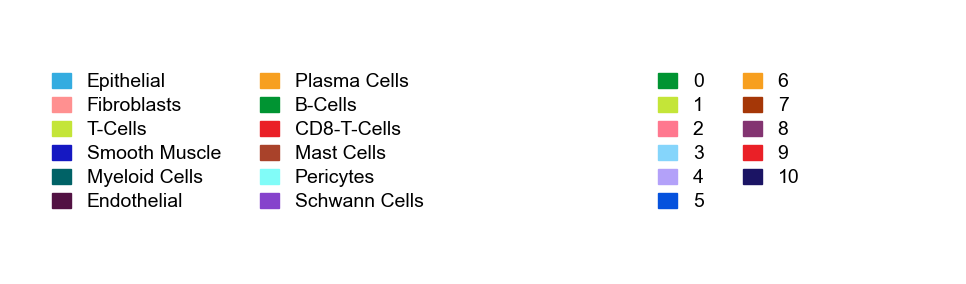

In [133]:
# ── Separate legend figure ───────────────────────────────────────────────────
# Order legend1 by cell count (most to least)
cell_counts = df["annotation_final_fine_cd8"].value_counts()
legend1_order = [k for k in cell_counts.index if k in palette_col1]
legend2_order = sorted(palette_col2.keys(), key=lambda x: int(x))

rename = {"CD8-T-Cell": "CD8-T-Cells"}

fig_leg, (ax_leg1, ax_leg2) = plt.subplots(1, 2, figsize=(10, 3))
ax_leg1.axis("off")
ax_leg2.axis("off")

handles1 = [mpatches.Patch(color=palette_col1[k], label=rename.get(k, k)) for k in legend1_order]
ax_leg1.legend(handles=handles1, title="", loc="center",
               fontsize=14, title_fontsize=14, frameon=False, ncol=2,
               handlelength=1, handleheight=0.8, labelspacing=0.3)

handles2 = [mpatches.Patch(color=palette_col2[k], label=k) for k in legend2_order]
ax_leg2.legend(handles=handles2, title="", loc="center",
               fontsize=14, title_fontsize=14, frameon=False, ncol=2,
               handlelength=1, handleheight=0.8, labelspacing=0.3)

fig_leg.tight_layout()
plt.savefig(os.path.join(output_dir, "all_cells_and_epi_clusts_legend.pdf"), dpi=300, bbox_inches="tight")

plt.show()

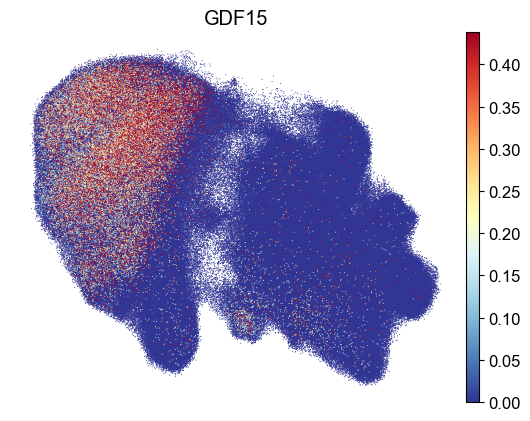

In [134]:
sc.settings._vector_friendly = True

ax = sc.pl.umap(adata_filtered, color="GDF15", show=False, size=2, title=None, legend_loc="none", cmap="RdYlBu_r", vmin="p1", vmax="p99")
ax.set_title("GDF15")
ax.set_axis_off()
plt.savefig(os.path.join(output_dir, "GDF15_all_cells_umap.pdf"), dpi=300, bbox_inches="tight")

plt.show()
sc.settings._vector_friendly = False


separate_N vs N: n=7
separate_N vs TA: n=10
separate_N vs CA: n=9
N vs TA: n=11
N vs CA: n=9
TA vs CA: n=12
      comparison  n   mean_a   mean_b     pval     padj
 separate_N vs N  7 0.005565 0.006636 0.468750 0.562500
separate_N vs TA 10 0.005118 0.039874 0.003906 0.005859
separate_N vs CA  9 0.005000 0.034293 0.003906 0.005859
         N vs TA 11 0.007910 0.033375 0.000977 0.005859
         N vs CA  9 0.005213 0.030885 0.003906 0.005859
        TA vs CA 12 0.035346 0.032688 0.677246 0.677246


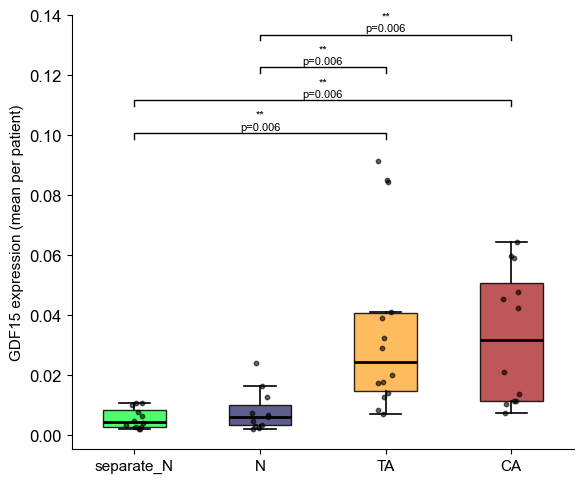

In [137]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# --- 1. Extract GDF15 expression ---
gene = "GDF15"
gene_idx = epi_adata.var_names.get_loc(gene)
X = epi_adata.X
if sparse.issparse(X):
    expr = np.array(X[:, gene_idx].todense()).flatten()
else:
    expr = X[:, gene_idx]

# --- 2. Build working DataFrame ---
df = pd.DataFrame({
    "GDF15":      expr,
    "core_id":    epi_adata.obs["core_id"].astype(str).values,
    "patient_id": epi_adata.obs["patient_id"].astype(str).values,
    "tissue_type": epi_adata.obs["tissue_type_cell_level_normal_split"].astype(str).values,
})

df = df[~df["tissue_type"].isin(["nan", "NA", "None"])]

# --- 3. Cell → Core → Patient mean ---
patient_means = (
    df.groupby(["patient_id", "core_id", "tissue_type"])["GDF15"]
    .mean()
    .reset_index()
    .groupby(["patient_id", "tissue_type"])["GDF15"]
    .mean()
    .reset_index()
)

# --- 4. Pairwise Wilcoxon, one pair at a time to maximise n ---
tissue_order = ["separate_N", "N", "TA", "CA"]
pairs = [("separate_N", "N"), ("separate_N", "TA"), ("separate_N", "CA"),
         ("N", "TA"), ("N", "CA"), ("TA", "CA")]

results = []
for a, b in pairs:
    pair_pivot = (
        patient_means.pivot_table(index="patient_id", columns="tissue_type", values="GDF15")
        [[a, b]].dropna()
    )
    print(f"{a} vs {b}: n={len(pair_pivot)}")
    if len(pair_pivot) < 3:
        print(f"  Skipping: too few paired observations")
        continue
    stat, pval = wilcoxon(pair_pivot[a].values, pair_pivot[b].values, alternative="two-sided")
    results.append({"comparison": f"{a} vs {b}", "a": a, "b": b,
                    "n": len(pair_pivot),
                    "mean_a": pair_pivot[a].mean(), "mean_b": pair_pivot[b].mean(),
                    "pval": pval,
                    "vals_a": pair_pivot[a].values,
                    "vals_b": pair_pivot[b].values})

results_df = pd.DataFrame(results)
_, padj, _, _ = multipletests(results_df["pval"], method="fdr_bh")
results_df["padj"] = padj
print(results_df[["comparison", "n", "mean_a", "mean_b", "pval", "padj"]].to_string(index=False))

# --- 5. Plot ---
def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

tissue_colors = {
    "separate_N": "#33fd55",
    "N":  "#40407a",
    "TA": "#ffb142",
    "CA": "#b33939",
}

all_pivot = patient_means.pivot_table(index="patient_id", columns="tissue_type", values="GDF15")
all_vals  = [all_pivot[tt].dropna().values for tt in tissue_order]
positions = np.arange(len(tissue_order))
colors    = [tissue_colors[tt] for tt in tissue_order]

fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(
    all_vals,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    showfliers=False,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for i, vals in enumerate(all_vals):
    jitter = np.random.uniform(-0.07, 0.07, size=len(vals))
    ax.scatter(i + jitter, vals, color="black", s=10, zorder=3, alpha=0.6)

# Staggered significance brackets
y_data_max = max([np.max(v) for v in all_vals])
y_base      = y_data_max * 1.08
foot_length = y_data_max * 0.02
bracket_step = y_data_max * 0.12

sig_idx = 0
for row in results_df.itertuples():
    if row.padj >= 0.05:
        continue
    pos_a = tissue_order.index(row.a)
    pos_b = tissue_order.index(row.b)
    y_top = y_base + sig_idx * bracket_step
    ax.plot([pos_a, pos_a, pos_b, pos_b],
            [y_top, y_top + foot_length, y_top + foot_length, y_top],
            color="black", linewidth=1.0)
    ax.text((pos_a + pos_b) / 2, y_top + foot_length * 1.3,
            f"{pval_to_stars(row.padj)}\np={row.padj:.3f}",
            ha="center", va="bottom", fontsize=8)
    sig_idx += 1

ax.set_xticks(positions)
ax.set_xticklabels(tissue_order, fontsize=11)
ax.set_ylabel("GDF15 expression (mean per patient)", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "GDF15_by_tissue_type_epi_normal_split.pdf"), dpi=300, bbox_inches="tight")
plt.show()